Connected to env (3.13.3) (Python 3.13.3)

In [ ]:
from multiprocessing.pool import INIT

import numpy as np
import random as rd
import time
import heapq



import matplotlib.pyplot as plt

In [ ]:
# Constante du progamme et initialisation des variables

L = 10 # Taille de la boite
N = 10 # Nombre de particule dans la boite

dt = 0.01 # delta T

vitesse = np.random.randint(0,5, size=(N,2)) # la vitesse de toute les particules

#vitesse = np.random.randn(N,2) # la vitesse de toute les particules
rayon = np.full(N, 0.5)  # rayon fixe pour toutes les particules/ permet de réduire l'erreur de conservation d'énergie
#rayon = np.random.uniform(0.1,0.5,size=N) # rayon aléatoire pour chaque particule
masse = np.random.uniform(size=N)

dimension = 2

X = np.zeros((N,dimension))



for i in range(N):
    X[i] = np.random.uniform(0,L,size = 2)

X = np.round(X,3)

In [ ]:
def collision (i, j):
    vitesse_relative = vitesse[i] - vitesse[j]
    centre_normalise = (X[i]-X[j])/np.linalg.norm(X[i] -X[j])
    vitesse_relative_normale = np.dot(vitesse_relative,centre_normalise)

    if vitesse_relative_normale >= 0: 
        return

    q = -2*np.dot(vitesse_relative,centre_normalise)*centre_normalise/(1/masse[i] + 1/masse[j]) 
    vitesse[i] = vitesse[i] + (q/masse[i])
    vitesse[j] = vitesse[j] - (q/masse[j])

energie cinétique initiale : 34.00061984485397
Risque de COLLISIOOOON
Collision entre particules 4 et 7 à la position [4.322 2.38 ] et [4.888 3.09 ]
Energie cinétique après collision : 32.10756604442657
Risque de COLLISIOOOON
Risque de COLLISIOOOON
Risque de COLLISIOOOON
Risque de COLLISIOOOON
Risque de COLLISIOOOON
Collision entre particules 2 et 8 à la position [7.389 6.855] et [7.907 7.709]
Energie cinétique après collision : 30.909318012291493


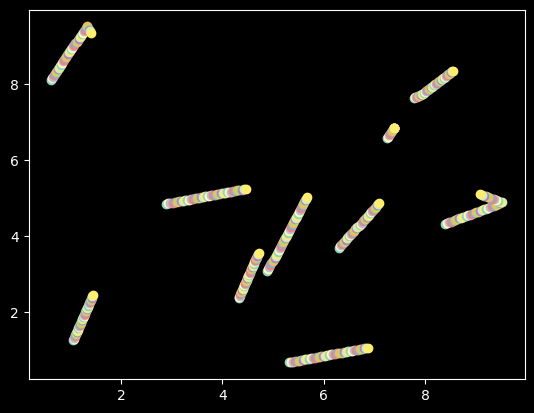

In [ ]:
# plt.scatter(X[:,0],X[:,1]) # position initial 

abscisse = X[:,0]
ordonnee = X[:,1]



# Calcul de l'énergie cinétique initiale
E=0
for i in range(N):
    E += 1/2*masse[i]*np.linalg.norm(vitesse[i])**2 

print('energie cinétique initiale :', E)

###########################################################
# Simulation de la dynamique des particules : Méthode 1 
###########################################################

for i in range(40):

    X = X + vitesse*dt
   
  #  plt.pause(0.5) # quand on mets pause on affiche graphe par graphe alors que sinon on a tout d'un coup
    plt.scatter(X[:,0],X[:,1]) # position initial 

    for i in range(N):
        if X[i, 0]  -rayon[i]<= 0 or X[i, 0] + rayon[i] >= L: # abscisse qui sort du cadre
            vitesse[i, 0] *= -1
        if X[i, 1] - rayon[i] <= 0 or X[i, 1] + rayon[i] >= L: # pareil pour l'ordonnée
            vitesse[i, 1] *= -1

        for j in range(i+1,N):
            dX = X[i] - X[j] 
            dist = np.linalg.norm(dX)
            dist_collision = rayon[i] + rayon[j]

            if dist>0 and dist<=dist_collision: # inégalité psq on aura jamais d'égalité stricte
                print("Risque de COLLISIOOOON")
               # time.sleep(3)
                
                vitesse_relative = vitesse[i] - vitesse[j]
        
                centre_normalise = (X[i]-X[j])/np.linalg.norm(X[i] -X[j]) 
                centre_normalise = dX/dist

                vitesse_relative_normale = np.dot(vitesse_relative,centre_normalise)
                vitesse_relative_normale = np.dot(vitesse_relative, dX) / dist

                if vitesse_relative_normale >= 0: 
                    # pour vérifier que les particules s'éloignent pas  mais qu'elles se rapprochent et donc qu'on a une collision 
                    # soit y en a une qui se rapproche + vite que l'autre ne s'éloigne 
                    # soit les deux se rapprochent 
                    continue

                q = -2*np.dot(vitesse_relative,centre_normalise)*centre_normalise/(1/masse[i] + 1/masse[j]) # on multiplie par le centre soit ici soit dans l'ajout de la vitesse
                #q = -2*vitesse_relative_normale/(1/masse[i] + 1/masse[j]) # si on utilise celle ci faut ajouter *centre_normalise dans l'ajout de la vitesse
                vitesse[i] = vitesse[i] + (q/masse[i])
                vitesse[j] = vitesse[j] - (q/masse[j])
                print(f"Collision entre particules {i} et {j} à la position {X[i]} et {X[j]}")

                E = 0
                for k in range(N):
                    E += 1/2*masse[k]*np.linalg.norm(vitesse[k])**2 
                print('Energie cinétique après collision :', E)
 
    ### vérifier, y a surement des erreur dans le calcul des collisions, pour la vitesse relative noprmal etc.
### on perd a chaque collision de l'énergie cinétique, 
# 

In [ ]:
def collision_time(i, j):

    r = X[i] - X[j] # position  relative
    v = vitesse[i] - vitesse[j] # vitesse relative
    R = rayon[i] + rayon[j]  # distance de collision

    a = np.dot(v, v)
    b = 2 * np.dot(r, v)
    c = np.dot(r, r) - R**2

    discriminant = b**2 - 4*a*c

    print(f"Calcul de collision_time entre particules {i} et {j}: a={a}, b={b}, c={c}, discriminant={discriminant}")

    if discriminant < 0:  # pas de solution réelle ou les particules sont à la même position et ont la même vitesse
        return None  # pas de collision
    
    if a == 0:  # les particules ont la même vitesse
        return -c/b if b != 0 else None  # collision si elles sont à la distance de collision, sinon pas de collision


    t1 = (-b - np.sqrt(discriminant)) / (2*a)
    t2 = (-b + np.sqrt(discriminant)) / (2*a)

    # on prend le plus petit temps positif
    t = min(t for t in [t1, t2] if t > 0) if any(t > 0 for t in [t1, t2]) else None

    return t




def collision_time_mur(i):

    times = []
    
    # Mur gauche (x=0)
    if vitesse[i, 0] < 0: # si son abscisse diminue
        t_left = (rayon[i] - X[i, 0]) / vitesse[i, 0]
        if t_left > 0:
            times.append(t_left)
    
    # Mur droit (x=L)
    if vitesse[i, 0] > 0: # si son abscisse augmente
        t_right = (L - rayon[i] - X[i, 0]) / vitesse[i, 0]
        if t_right > 0:
            times.append(t_right)
    
    # Mur bas (y=0)
    if vitesse[i, 1] < 0: # si son ordonnée diminue
        t_bottom = (rayon[i] - X[i, 1]) / vitesse[i, 1]
        if t_bottom > 0:
            times.append(t_bottom)
    
    # Mur haut (y=L)
    if vitesse[i, 1] > 0:  # si son ordonnée augmente
        t_top = (L - rayon[i] - X[i, 1]) / vitesse[i, 1]
        if t_top > 0:
            times.append(t_top)
    
    if times:
        return min(times)
    
    return None

In [ ]:
def collision_time(i, j):

    r = X[i] - X[j] # position  relative
    v = vitesse[i] - vitesse[j] # vitesse relative
    R = rayon[i] + rayon[j]  # distance de collision

    a = np.dot(v, v)
    b = 2 * np.dot(r, v)
    c = np.dot(r, r) - R**2

    discriminant = b**2 - 4*a*c

    print(f"Calcul de collision_time entre particules {i} et {j}: a={a}, b={b}, c={c}, discriminant={discriminant}")

    if discriminant < 0:  # pas de solution réelle ou les particules sont à la même position et ont la même vitesse
        return None  # pas de collision
    
    if a == 0:  # les particules ont la même vitesse
        return -c/b if b != 0 else None  # collision si elles sont à la distance de collision, sinon pas de collision


    t1 = (-b - np.sqrt(discriminant)) / (2*a)
    t2 = (-b + np.sqrt(discriminant)) / (2*a)

    # on prend le plus petit temps positif
    t = min(t for t in [t1, t2] if t > 0) if any(t > 0 for t in [t1, t2]) else None

    return t




def collision_time_mur(i):

    times = []
    
    # Mur gauche (x=0)
    if vitesse[i, 0] < 0: # si son abscisse diminue
        t_left = (rayon[i] - X[i, 0]) / vitesse[i, 0]
        if t_left > 0:
            times.append(t_left)
    
    # Mur droit (x=L)
    if vitesse[i, 0] > 0: # si son abscisse augmente
        t_right = (L - rayon[i] - X[i, 0]) / vitesse[i, 0]
        if t_right > 0:
            times.append(t_right)
    
    # Mur bas (y=0)
    if vitesse[i, 1] < 0: # si son ordonnée diminue
        t_bottom = (rayon[i] - X[i, 1]) / vitesse[i, 1]
        if t_bottom > 0:
            times.append(t_bottom)
    
    # Mur haut (y=L)
    if vitesse[i, 1] > 0:  # si son ordonnée augmente
        t_top = (L - rayon[i] - X[i, 1]) / vitesse[i, 1]
        if t_top > 0:
            times.append(t_top)
    
    if times:
        return min(times)
    
    return None

Calcul de collision_time entre particules 0 et 1: a=8, b=14.328000000000088, c=13.463434000000024, discriminant=-225.53830399999825
Calcul de collision_time entre particules 0 et 2: a=13, b=-13.134000000000029, c=3.033860999999992, discriminant=14.74118400000117
Collision entre particules 0 et 2 dans 0.36 secondes.
Calcul de collision_time entre particules 0 et 3: a=37, b=-24.339999999999975, c=3.011816999999996, discriminant=146.68668399999933
Collision entre particules 0 et 3 dans 0.17 secondes.
Calcul de collision_time entre particules 0 et 4: a=1, b=4.741999999999985, c=6.364040999999997, discriminant=-2.9696000000001312
Calcul de collision_time entre particules 0 et 5: a=49, b=-62.71999999999956, c=51.31008399999952, discriminant=-6122.978063999961
Calcul de collision_time entre particules 0 et 6: a=8, b=-11.999999999999876, c=6.035751999999894, discriminant=-49.14406399999959
Calcul de collision_time entre particules 0 et 7: a=4, b=0.6799999999999535, c=1.0311249999999963, discri

[(np.float64(0.13353170784129403), (6, 7)),
 (np.float64(0.3808946785157724), (2, 3)),
 (np.float64(0.16525097531562533), (0, 3)),
 (np.float64(0.4765000000000086), (8, None)),
 (np.float64(0.4584675638058641), (3, 6)),
 (np.float64(0.6575847495031568), (2, 6)),
 (np.float64(0.3574836555021713), (0, 2)),
 (np.float64(0.7528457674007467), (3, 4)),
 (np.float64(1.2085000000000083), (0, None)),
 (np.float64(0.6579999999999997), (1, None)),
 (np.float64(1.983333333333336), (4, None)),
 (np.float64(2.2124999999999932), (5, None)),
 (np.float64(0.9162863743691907), (5, 9)),
 (np.float64(1.2607499999999996), (6, None)),
 (np.float64(0.36053788888035804), (2, 7)),
 (np.float64(2.1429999999999962), (3, None)),
 (np.float64(0.8920000000000015), (7, None)),
 (np.float64(2.351000000000001), (9, None))]

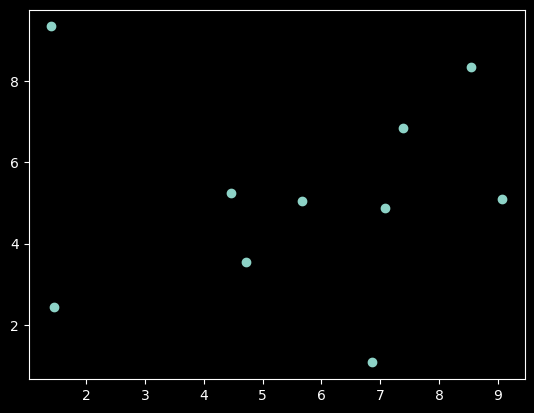

In [ ]:
plt.scatter(X[:,0],X[:,1]) # position initial 
events = []

def init_events():

    # Initialisation des événements de collision
    for i in range(N):
        t_mur = collision_time_mur(i)
        if t_mur is not None:
            heapq.heappush(events, (t_mur, (i, None)))
        for j in range(i+1,N):
                        t = collision_time(i, j)

                        if t is not None:
                            print(f"Collision entre particules {i} et {j} dans {t:.2f} secondes.")
                            heapq.heappush(events, (t, (i, j)))
    return events

init_events()

# print(heapq.heappop(events))

Calcul de collision_time entre particules 0 et 1: a=8, b=16.46450732546079, c=15.519322045942193, discriminant=-225.53830399999816
Calcul de collision_time entre particules 0 et 2: a=13, b=-9.662175596126385, c=1.5118548701995982, discriminant=14.741184000001155
Collision entre particules 0 et 2 dans 0.22 secondes.
Calcul de collision_time entre particules 0 et 3: a=37, b=-14.458653619744215, c=0.42139176010637214, discriminant=146.68668399999945
Collision entre particules 0 et 3 dans 0.03 secondes.
Calcul de collision_time entre particules 0 et 4: a=1, b=5.009063415682574, c=7.015079075582426, discriminant=-2.9696000000001277
Calcul de collision_time entre particules 0 et 5: a=49, b=-49.63389263155274, c=43.80868041714524, discriminant=-6122.978063999962
Calcul de collision_time entre particules 0 et 6: a=10, b=-5.359492674539181, c=4.5760172418964835, discriminant=-154.31652794742018
Calcul de collision_time entre particules 0 et 7: a=4, b=1.7482536627303062, c=1.1932494293281208, di

np.int64(2)

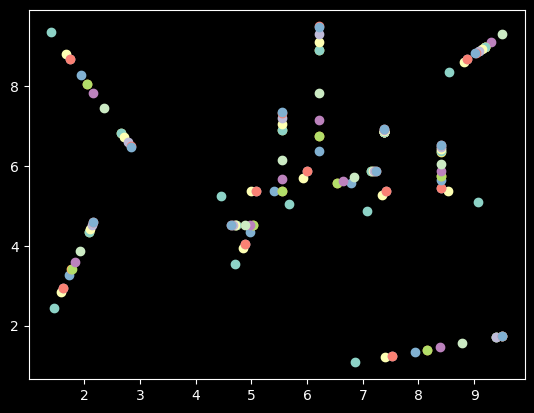

In [ ]:
NB_ITER = 15
INIT = False
while True and NB_ITER > 0:
    NB_ITER -= 1
    if not events:
        break  # sortir si plus d'événements

    # plt.pause(1) 
    plt.scatter(X[:,0],X[:,1]) # position initial 


    t, (a, b) = heapq.heappop(events)

    if t < 1e-10:  # ignorer les collisions trop proches (quasi-instantanées)
        continue

    for k in range(N):
        X[k] += vitesse[k] * t

    if b is None:  # collision avec le mur
        vitesse[a] *= -1  # inverser la vitesse de la particule
    else:  # collision entre particules
        collision(a, b)

#### Revoir cette partie
    if INIT == True : 
        for j in range(N):
            if j == a or j == b:
                continue  # éviter de reprogrammer la collision actuelle

            if b is None:
                collision_time_mur_a = collision_time_mur(a)
                if collision_time_mur_a is not None and collision_time_mur_a > 1e-10:
                    heapq.heappush(events, (collision_time_mur_a, (a, None)))
                    
            else:

                ta = collision_time(a, j)
                tb = collision_time(b, j)

                collision_time_mur_a = collision_time_mur(a)
                collision_time_mur_b = collision_time_mur(b)

                if collision_time_mur_a is not None and collision_time_mur_a > 1e-10:
                    heapq.heappush(events, (collision_time_mur_a, (a, None)))
                if collision_time_mur_b is not None and collision_time_mur_b > 1e-10:
                    heapq.heappush(events, (collision_time_mur_b, (b, None)))

                if ta is not None and ta > 1e-10:
                    print(f"Collision entre particules {a} et {j} dans {ta:.4f} secondes.")
                    heapq.heappush(events, (ta, (a, j)))

                if tb is not None and tb > 1e-10:
                    print(f"Collision entre particules {b} et {j} dans {tb:.4f} secondes.")
                    heapq.heappush(events, (tb, (b, j)))
    else :
        init_events()  # réinitialiser tous les événements après une collision




X[0]
X[2]

vitesse[0]

vitesse[2]
vitesse_relative = vitesse[0] - vitesse[2]

np.dot(vitesse_relative,vitesse_relative)